In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def load_json_to_df(filename):
    filepath = f"data_exports/{filename}.json"
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found.")
        return pd.DataFrame()
    with open(filepath, 'r', encoding='utf-8') as f:
        return pd.DataFrame(json.load(f))

# Load the datasets
print("Loading datasets...")
df_catalog = load_json_to_df("bucket_A_catalog")
df_models = load_json_to_df("bucket_B_models")
df_comments = load_json_to_df("bucket_C_comments")
df_diagnostics = load_json_to_df("bucket_C_diagnostics")

print("Data loaded successfully!")

Data loaded. Processing insights...

 📊 ITEM CATALOG & SALES INSIGHTS
1. Total Unique Items: 299
2. Total Items Sold (All Time): 0
3 & 4. Most/Least Bought: Could not determine (sales data might be hidden/0).

5. Item with the MOST 5-Star Ratings:
   -> [BS] Painting by Number Children Canvas ... (994 reviews)
6. Item with the MOST 1-Star Ratings:
   -> [BS] DIY Merajut Anak Edukasi Montessori... (3 reviews)


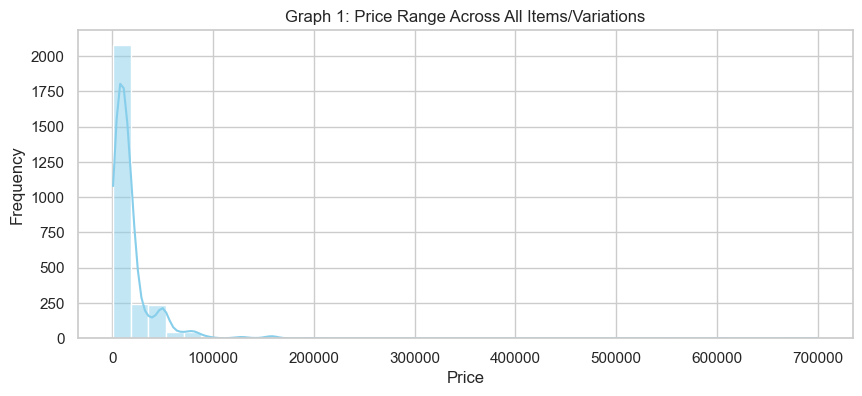

C:\Users\HP\AppData\Local\Temp\ipykernel_29888\3216685235.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_comments, x='rating_star', palette='RdYlGn')


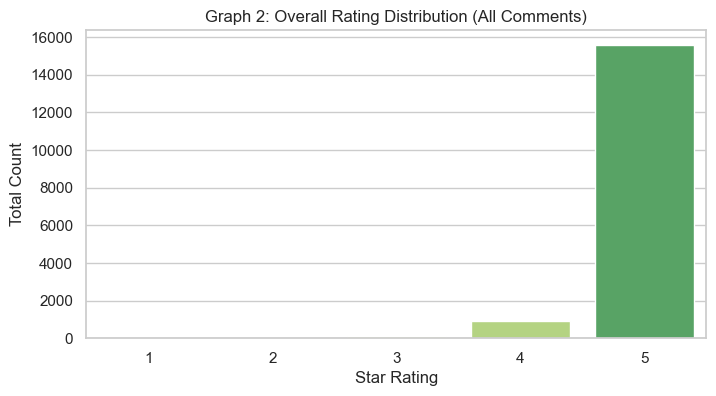

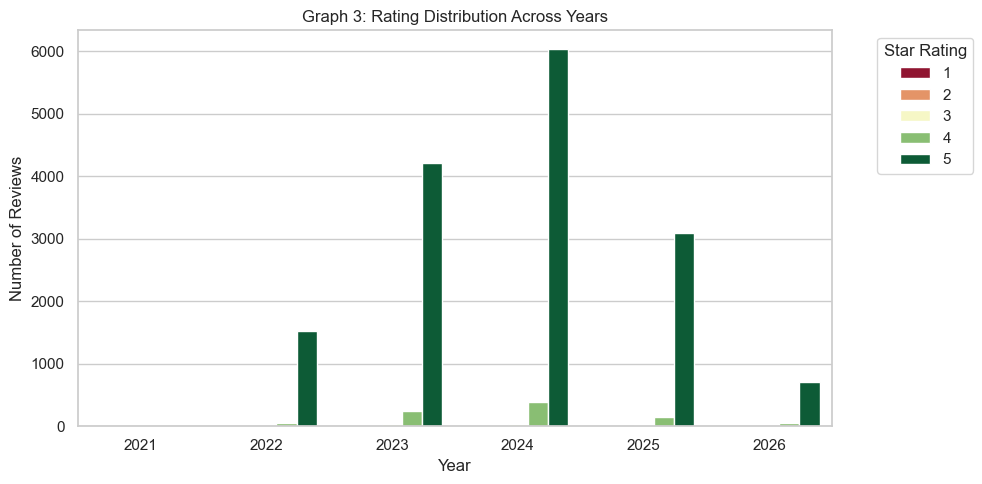

In [8]:
# --- 1. Load Data ---
def load_json_to_df(filename):
    filepath = f"data_exports/{filename}.json"
    if not os.path.exists(filepath):
        return pd.DataFrame()
    with open(filepath, 'r', encoding='utf-8') as f:
        return pd.DataFrame(json.load(f))

df_catalog = load_json_to_df("bucket_A_catalog")
df_models = load_json_to_df("bucket_B_models")
df_comments = load_json_to_df("bucket_C_comments")

print("Data loaded. Processing insights...\n")
print("="*50)
print(" 📊 ITEM CATALOG & SALES INSIGHTS")
print("="*50)

# --- 2. Process Catalog & Sales ---
catalog_list = []
for _, row in df_catalog.iterrows():
    # Attempt to safely get historical sold. Shopee sometimes uses 'historical_sold', 'sold', or nests it.
    sold_count = row.get('historical_sold', 0) 
    if pd.isna(sold_count): sold_count = 0
        
    catalog_list.append({
        'item_id': row.get('item_id'),
        'item_name': str(row.get('item_name', 'Unknown Name'))[:40] + '...',
        'sold': int(sold_count)
    })

df_cat_clean = pd.DataFrame(catalog_list)

# Metrics
total_items = len(df_cat_clean)
total_sold = df_cat_clean['sold'].sum()
most_bought = df_cat_clean.loc[df_cat_clean['sold'].idxmax()] if total_sold > 0 else None
least_bought = df_cat_clean.loc[df_cat_clean['sold'].idxmin()] if total_sold > 0 else None

print(f"1. Total Unique Items: {total_items}")
print(f"2. Total Items Sold (All Time): {total_sold:,}")

if most_bought is not None:
    print(f"3. Most Bought Item: {most_bought['item_name']} ({most_bought['sold']:,} sold)")
    print(f"4. Least Bought Item: {least_bought['item_name']} ({least_bought['sold']:,} sold)")
else:
    print("3 & 4. Most/Least Bought: Could not determine (sales data might be hidden/0).")


# --- 3. Process Best & Worst Reviewed Items ---
if not df_comments.empty:
    df_comments['rating_star'] = pd.to_numeric(df_comments.get('rating_star', 0), errors='coerce')
    
    # Map item names to comments for readability
    id_to_name = dict(zip(df_cat_clean['item_id'], df_cat_clean['item_name']))
    df_comments['item_name'] = df_comments['item_id'].map(id_to_name)
    
    # Filter 5-star and 1-star
    five_stars = df_comments[df_comments['rating_star'] == 5]
    one_stars = df_comments[df_comments['rating_star'] == 1]
    
    most_5_star = five_stars['item_name'].value_counts().head(1)
    most_1_star = one_stars['item_name'].value_counts().head(1)
    
    print("\n5. Item with the MOST 5-Star Ratings:")
    if not most_5_star.empty:
        print(f"   -> {most_5_star.index[0]} ({most_5_star.values[0]} reviews)")
    else:
        print("   -> No 5-star ratings found.")
        
    print("6. Item with the MOST 1-Star Ratings:")
    if not most_1_star.empty:
        print(f"   -> {most_1_star.index[0]} ({most_1_star.values[0]} reviews)")
    else:
        print("   -> Awesome! No 1-star ratings found.")
        
print("="*50)


# --- 4. GRAPH 1: Price Range (from Bucket B) ---
if not df_models.empty:
    prices = []
    for _, row in df_models.iterrows():
        models_list = row.get('models', [])
        if isinstance(models_list, list):
            for model in models_list:
                price_data = model.get('price_info')
                current_price = 0
                if isinstance(price_data, list) and len(price_data) > 0:
                    current_price = price_data[0].get('current_price', 0)
                elif isinstance(price_data, dict):
                    current_price = price_data.get('current_price', 0)
                if current_price > 0:
                    prices.append(current_price)
                    
    if prices:
        plt.figure(figsize=(10, 4))
        sns.histplot(prices, bins=40, color='skyblue', kde=True)
        plt.title('Graph 1: Price Range Across All Items/Variations')
        plt.xlabel('Price')
        plt.ylabel('Frequency')
        plt.show()

# --- 5. GRAPH 2: Rating Distribution Across All Items ---
if not df_comments.empty:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_comments, x='rating_star', palette='RdYlGn')
    plt.title('Graph 2: Overall Rating Distribution (All Comments)')
    plt.xlabel('Star Rating')
    plt.ylabel('Total Count')
    plt.show()

# --- 6. GRAPH 3: Rating Distribution Across Years ---
if not df_comments.empty and 'create_time' in df_comments.columns:
    # Convert UNIX timestamp to Year
    df_comments['year'] = pd.to_datetime(df_comments['create_time'], unit='s', errors='coerce').dt.year
    
    # Drop any rows where year couldn't be parsed
    df_comments_yearly = df_comments.dropna(subset=['year']).copy()
    df_comments_yearly['year'] = df_comments_yearly['year'].astype(int)
    
    if not df_comments_yearly.empty:
        # Group by Year and Rating
        yearly_ratings = df_comments_yearly.groupby(['year', 'rating_star']).size().reset_index(name='count')
        
        plt.figure(figsize=(10, 5))
        sns.barplot(data=yearly_ratings, x='year', y='count', hue='rating_star', palette='RdYlGn')
        plt.title('Graph 3: Rating Distribution Across Years')
        plt.xlabel('Year')
        plt.ylabel('Number of Reviews')
        plt.legend(title='Star Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

In [11]:
import pandas as pd
from llama_index.core import Document

def create_rag_documents(df_catalog, df_comments, shop_name="Our Store"):
    documents = []
    
    # 1. Create Shop Info Document
    shop_doc = Document(
        text=f"Welcome to {shop_name}. We are a verified Shopee seller. Please ask me any questions about our products, stock, or customer reviews.",
        metadata={"type": "shop_info", "item_id": "GLOBAL"}
    )
    # Exclude metadata from the actual embedded text to save tokens
    shop_doc.excluded_embed_metadata_keys = ["type", "item_id"]
    documents.append(shop_doc)
    
    # 2. Create Product Documents (Bucket A)
    if not df_catalog.empty:
        for _, row in df_catalog.iterrows():
            item_id = str(row.get('item_id', ''))
            name = str(row.get('item_name', 'Unknown Product'))
            desc = str(row.get('description', 'No description available.')).replace('\n', ' ')
            
            # Textify the product info
            text_payload = f"Product Name: {name}. \nProduct Description: {desc}"
            
            doc = Document(
                text=text_payload,
                metadata={
                    "type": "product_info",
                    "item_id": item_id,
                    "item_name": name
                }
            )
            doc.excluded_embed_metadata_keys = ["type", "item_id"]
            documents.append(doc)
            
    # 3. Create Review Documents (Bucket C)
    if not df_comments.empty:
        # Create a dictionary to look up item names by ID
        id_to_name = dict(zip(df_catalog['item_id'].astype(str), df_catalog['item_name']))
        
        for _, row in df_comments.iterrows():
            item_id = str(row.get('item_id', ''))
            item_name = id_to_name.get(item_id, "this product")
            comment_text = str(row.get('comment', '')).replace('\n', ' ').strip()
            rating = float(row.get('rating_star', 0))
            
            # Skip empty comments
            if not comment_text: 
                continue
                
            # Classify sentiment for metadata filtering
            sentiment = "positive" if rating >= 4 else ("neutral" if rating == 3 else "negative")
            
            # Textify the review
            text_payload = f"A customer reviewed the product '{item_name}' and gave it {rating} out of 5 stars. They stated: '{comment_text}'"
            
            doc = Document(
                text=text_payload,
                metadata={
                    "type": "review",
                    "item_id": item_id,
                    "sentiment": sentiment,
                    "rating": rating
                }
            )
            doc.excluded_embed_metadata_keys = ["type", "item_id", "sentiment", "rating"]
            documents.append(doc)
            
    print(f"Successfully generated {len(documents)} LlamaIndex Documents!")
    return documents

rag_docs = create_rag_documents(df_catalog, df_comments)

Successfully generated 2625 LlamaIndex Documents!
